In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
data = pd.read_csv("heart.csv")

print("Dataset Loaded Successfully")

print(data.head())

Dataset Loaded Successfully
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [3]:
print(data.shape)

print(data.info())

print(data.isnull().sum())

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtyp

In [4]:
X = data.drop("target", axis=1)

y = data["target"]

print(X.head())

print(y.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  
0   2     3  
1   0     3  
2   0     3  
3   1     3  
4   3     2  
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(717, 13)
(308, 13)


In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [7]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [8]:
dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained")

Decision Tree Model Trained


In [9]:
dt_prediction = dt_model.predict(X_test)

print(dt_prediction)

[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 0 0 1 0 0 1 1 1 0 1 0 1 1 1 1 1 0
 1 1 1 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 0 0 1
 1 1 0 1 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0 1 0 1 1 0 1 0 1 0 1 1
 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 1
 1 0 1 0 1 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1
 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0
 0 1 1 1 1 1 0 1 0 0 1 1 0 0 0 0 1 0 1 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0
 1 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1 0 1
 1 0 0 1 1 0 1 1 1 0 0 1]


In [10]:
dt_accuracy = accuracy_score(y_test, dt_prediction)

print("Decision Tree Accuracy :",
      round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy : 83.44 %


In [11]:
print(confusion_matrix(y_test, dt_prediction))

[[121  38]
 [ 13 136]]


[[121  38]
 [ 13 136]]


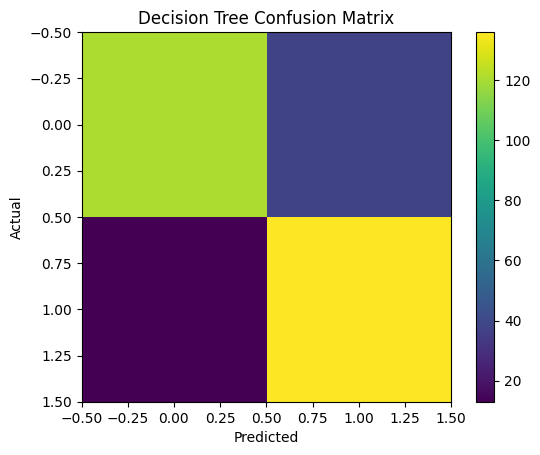

In [33]:
dt_cm = confusion_matrix(y_test, dt_prediction)

print(dt_cm)

plt.imshow(dt_cm)

plt.title("Decision Tree Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [12]:
print(classification_report(y_test, dt_prediction))

              precision    recall  f1-score   support

           0       0.90      0.76      0.83       159
           1       0.78      0.91      0.84       149

    accuracy                           0.83       308
   macro avg       0.84      0.84      0.83       308
weighted avg       0.84      0.83      0.83       308



In [13]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42
)

In [14]:
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained")

Random Forest Model Trained


In [15]:
rf_prediction = rf_model.predict(X_test)

print(rf_prediction)

[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1
 1 1 1 0 0 1 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 0 1 1 0 0 1
 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0 1 0 1 1
 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 1 0 1 0 1 1 0 1 1 1 0 1 1 1 1
 1 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 1
 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0 0 1 0 1 0
 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 1 0
 1 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1
 1 0 0 1 1 0 1 1 1 0 0 1]


In [16]:
rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Random Forest Accuracy :",
      round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy : 88.96 %


In [17]:
print(confusion_matrix(y_test, rf_prediction))

[[130  29]
 [  5 144]]


[[130  29]
 [  5 144]]


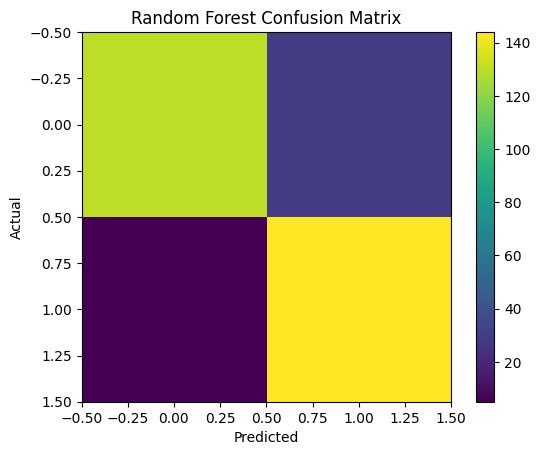

In [34]:
rf_cm = confusion_matrix(y_test, rf_prediction)

print(rf_cm)

plt.imshow(rf_cm)

plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [18]:
print(classification_report(y_test, rf_prediction))

              precision    recall  f1-score   support

           0       0.96      0.82      0.88       159
           1       0.83      0.97      0.89       149

    accuracy                           0.89       308
   macro avg       0.90      0.89      0.89       308
weighted avg       0.90      0.89      0.89       308



In [19]:
nb_model = GaussianNB()

In [20]:
nb_model.fit(X_train, y_train)

print("Naive Bayes Model Trained")

Naive Bayes Model Trained


In [21]:
nb_prediction = nb_model.predict(X_test)

print(nb_prediction)

[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1
 1 1 1 0 0 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 1 0 1 1
 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 1 1 1 1
 1 1 0 1 1 0 1 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 1 0 1 1 1 1
 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 0 0 0 1 0 1 0
 0 1 1 1 1 1 0 1 1 0 1 1 0 0 0 0 1 0 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0
 1 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 1 1 1 0 0
 1 0 1 1 1 0 1 1 0 0 0 1]


In [22]:
nb_accuracy = accuracy_score(y_test, nb_prediction)

print("Naive Bayes Accuracy :",
      round(nb_accuracy * 100, 2), "%")

Naive Bayes Accuracy : 81.49 %


In [23]:
print(confusion_matrix(y_test, nb_prediction))

[[118  41]
 [ 16 133]]


[[118  41]
 [ 16 133]]


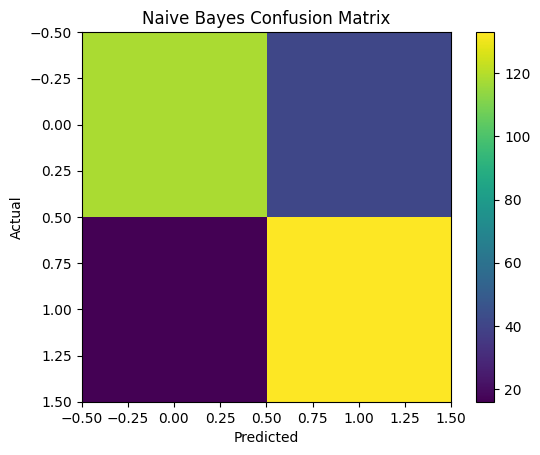

In [35]:
nb_cm = confusion_matrix(y_test, nb_prediction)

print(nb_cm)

plt.imshow(nb_cm)

plt.title("Naive Bayes Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [24]:
print(classification_report(y_test, nb_prediction))

              precision    recall  f1-score   support

           0       0.88      0.74      0.81       159
           1       0.76      0.89      0.82       149

    accuracy                           0.81       308
   macro avg       0.82      0.82      0.81       308
weighted avg       0.82      0.81      0.81       308



In [25]:
svm_model = SVC(
    kernel='linear',
    C=0.5
)

In [26]:
svm_model.fit(X_train, y_train)

print("SVM Model Trained")

SVM Model Trained


In [27]:
svm_prediction = svm_model.predict(X_test)

print(svm_prediction)

[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1 1 1
 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 0 0 0 1 0 0 1 1 0 1 1 0 0 1
 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1
 1 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1
 1 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 1 0 0 1 0 1 0 1 0
 0 1 1 1 1 1 0 0 1 0 1 1 0 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0
 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1
 1 0 0 1 1 0 1 1 1 0 0 1]


In [28]:
svm_accuracy = accuracy_score(y_test, svm_prediction)

print("SVM Accuracy :",
      round(svm_accuracy * 100, 2), "%")

SVM Accuracy : 80.84 %


In [29]:
print(confusion_matrix(y_test, svm_prediction))

[[119  40]
 [ 19 130]]


[[119  40]
 [ 19 130]]


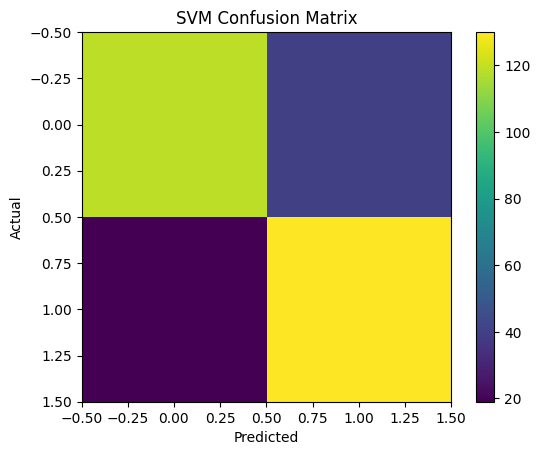

In [36]:
svm_cm = confusion_matrix(y_test, svm_prediction)

print(svm_cm)

plt.imshow(svm_cm)

plt.title("SVM Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [30]:
print(classification_report(y_test, svm_prediction))

              precision    recall  f1-score   support

           0       0.86      0.75      0.80       159
           1       0.76      0.87      0.82       149

    accuracy                           0.81       308
   macro avg       0.81      0.81      0.81       308
weighted avg       0.82      0.81      0.81       308



In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
lr_model = LogisticRegression()

In [39]:
lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained")

Logistic Regression Model Trained


In [44]:
lr_prediction = lr_model.predict(X_test)

print(lr_prediction)

[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1 1 1
 0 1 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1
 1 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1
 1 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1
 1 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1 0 1 1 0 0 1 0 1 0 1 0
 0 1 1 1 1 1 0 0 1 0 1 1 0 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 1 0
 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1
 1 0 0 1 1 0 1 1 1 0 0 1]


In [41]:
lr_accuracy = accuracy_score(y_test, lr_prediction)

print("Logistic Regression Accuracy :",
      round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy : 80.52 %


[[119  40]
 [ 20 129]]


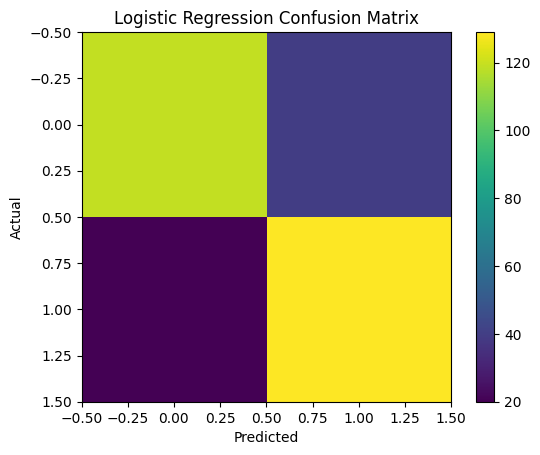

In [42]:
lr_cm = confusion_matrix(y_test, lr_prediction)

print(lr_cm)

plt.imshow(lr_cm)

plt.title("Logistic Regression Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

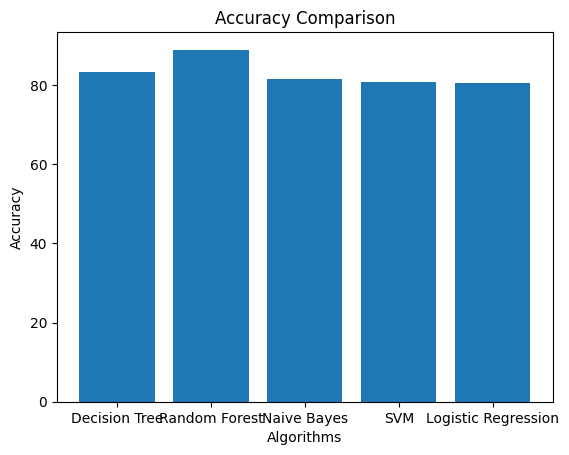

In [43]:
models = [
    "Decision Tree",
    "Random Forest",
    "Naive Bayes",
    "SVM",
    "Logistic Regression"
]

accuracy = [
    dt_accuracy * 100,
    rf_accuracy * 100,
    nb_accuracy * 100,
    svm_accuracy * 100,
    lr_accuracy * 100
]

plt.bar(models, accuracy)

plt.xlabel("Algorithms")

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.show()

In [45]:
print("Decision Tree Accuracy :",
      round(dt_accuracy * 100, 2), "%")

print("Random Forest Accuracy :",
      round(rf_accuracy * 100, 2), "%")

print("Naive Bayes Accuracy :",
      round(nb_accuracy * 100, 2), "%")

print("SVM Accuracy :",
      round(svm_accuracy * 100, 2), "%")

print("Logistic Regression Accuracy :",
      round(lr_accuracy * 100, 2), "%")

Decision Tree Accuracy : 83.44 %
Random Forest Accuracy : 88.96 %
Naive Bayes Accuracy : 81.49 %
SVM Accuracy : 80.84 %
Logistic Regression Accuracy : 80.52 %
